In [1]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./images/intermediate_data_viz.png",width=450)

## Chapter Overview

In the previous chapter, you mastered the fundamentals of creating plots using pandas, matplotlib's pyplot interface, and seaborn. You learned to create individual visualizations like scatter plots, line plots, bar plots, and statistical plots. 

This chapter advances your visualization skills by focusing on:

- **Matplotlib's object-oriented interface** for fine-grained control
- **Complex multi-panel layouts** with sophisticated subplots
- **Advanced seaborn techniques** for multi-dimensional data exploration
- **Geospatial visualization** for mapping and location-based data

By the end of this chapter, you'll be able to create publication-quality, complex visualizations that combine multiple data views and handle specialized data types like geographic information.

To get started, let's import necessary libraries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Matplotlib’s Two Interfaces

Matplotlib provides **two main interfaces** for creating visualizations: the **pyplot interface** and the **object-oriented (OOP) interface**.

![](images/matplotlib_interfaces.png)

In the previous chapter, we primarily used the **pyplot interface** — a convenient, MATLAB-style approach where functions such as `plt.plot()` and `plt.xlabel()` operate on an implicit *“current”* figure and axes.

The **object-oriented (OOP) interface**, on the other hand, offers **explicit control** over every element of your plot. It’s the preferred approach for building **complex layouts**, **multiple subplots**, or **publication-quality figures** where precision and flexibility matter.


### Compare Pyplot vs Object-Oriented Interfaces

Let's create the same plot using both interfaces to see the difference in syntax and approach.


We'll use a dataset containing GDP and life expectancy data for countries.

In [3]:
# Load the dataset
gdp_data = pd.read_csv('datasets/gdp_lifeExpectancy.csv')
gdp_data.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


#### Pyplot Interface (Implicit)

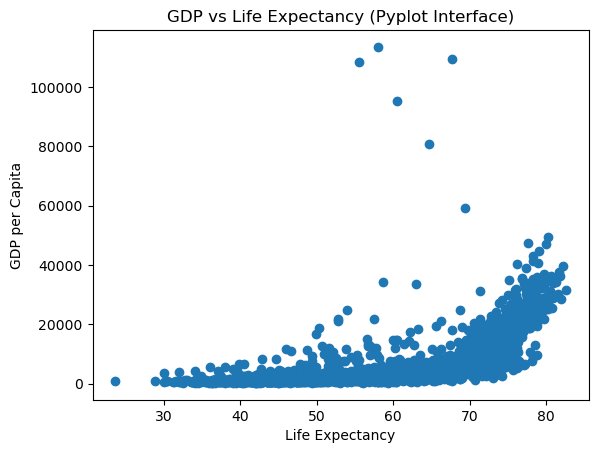

In [4]:
# Pyplot interface - operates on the "current" figure/axes
plt.scatter(gdp_data.lifeExp, gdp_data.gdpPercap)
plt.xlabel('Life Expectancy')
plt.ylabel('GDP per Capita')
plt.title('GDP vs Life Expectancy (Pyplot Interface)');

#### Object-Oriented Interface (Explicit)

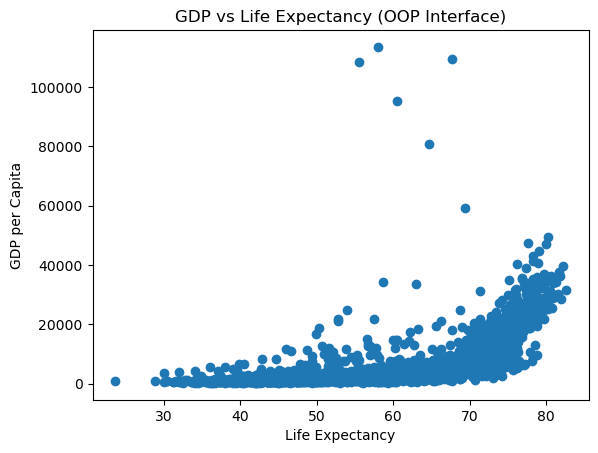

In [5]:
# Object-oriented interface
fig, ax = plt.subplots()  # Create a figure and an axes explicitly

# Plot on the specific axes object
ax.scatter(gdp_data.lifeExp, gdp_data.gdpPercap)
ax.set_xlabel('Life Expectancy')
ax.set_ylabel('GDP per Capita')
ax.set_title('GDP vs Life Expectancy (OOP Interface)');

**Key Observations:**

Both approaches produce identical plots, but notice the differences:

- **Pyplot Interface:** 
  
   - Simpler syntax: `plt.scatter()`, `plt.xlabel()`
   - Operates on implicit "current" figure
   - Great for quick, simple plots
   - Less control when working with multiple subplots

- **Object-Oriented Interface:**
  
   - Explicit syntax: `ax.scatter()`, `ax.set_xlabel()`
   - Direct control over specific axes object
   - Essential for complex layouts
   - Can pass axes to pandas/seaborn functions
   - More verbose but more flexible


####  Pyplot: A Convenience Wrapper

The **`pyplot`** interface (e.g., `plt.plot()`) is a *convenience layer* built on top of Matplotlib’s **object-oriented (OOP)** interface.

Behind the scenes, it:

- Automatically creates a **Figure** and **Axes** if they don’t already exist  
- Keeps track of the **“current”** figure and axes  
- Routes plotting commands to that current axes object  

This makes `pyplot` extremely convenient for **quick, one-off plots** or **exploratory analysis**,  
but it can quickly become **confusing or limiting** when working with **multiple figures or subplots**.


####  When the OOP Interface Becomes Essential

While `pyplot` is great for simplicity, the **OOP interface** (`fig, ax = plt.subplots()`) is the right choice for:

- Creating **multiple subplots** within a single figure  
- Building **complex layouts** or **publication-quality plots**  
- Integrating with **pandas** or **seaborn**, which both accept an `ax` parameter — allowing you to specify **exactly where** a plot should appear (something `pyplot` alone cannot do)

### Understand the Matplotlib Object Hierarchy

To work effectively with matplotlib's OOP interface, you need to understand how plot components are organized.

#### The Hierarchical Structure

Matplotlib plots follow a **hierarchical structure**, with two core components:

* **Figure:** The overall container for one or more plots (the entire window/canvas)
* **Axes:** The individual plot area where data is visualized (what you think of as "a plot")

Each Axes contains further elements such as:

* **Axis** (x-axis and y-axis) - the number lines with ticks and labels
* **Title**, **Labels**, **Ticks** - text and markers
* **Drawable objects** like Lines, Text, and Patches (collectively called **Artists**)

Here's the hierarchy visualized:

```
Figure (the entire canvas)
 └── Axes (1 or more plot areas)
      ├── XAxis, YAxis (the number lines)
      │    ├── Axis Labels
      │    ├── Tick Marks
      │    └── Tick Labels
      ├── Title
      ├── Legend
      └── Artist objects (Lines, Patches, Text, Collections, etc.)
```

**Important Terminology:**

- **Figure** = The entire window/image (can contain multiple plots)
- **Axes** = A single plot area (confusingly NOT the axis lines!)
- **Axis** = The x-axis or y-axis number line

Understanding this structure is key to using Matplotlib's object-oriented interface, as it allows you to **access and customize each component directly**.

#### Figure: The Top-Level Container

The `Figure` is an instance of `matplotlib.figure.Figure`. It is the **top level container** for all plot elements - think of it as the canvas or paper on which you draw. 

**Key points about Figure:**

- It's the final image that may contain one or more Axes
- It keeps track of all the Axes, titles, legends, etc.
- You cannot plot data directly on a Figure (only on Axes)
- It controls the overall image size, DPI, background color

Let's create an empty Figure to see what it looks like:

In [6]:
# Create an empty figure - just the container, no plots yet
fig = plt.figure(figsize=(8, 6))
print(f"Figure object: {fig}")
print(f"Number of axes in figure: {len(fig.axes)}")

Figure object: Figure(800x600)
Number of axes in figure: 0


<Figure size 800x600 with 0 Axes>

**Observation:** The Figure is just a blank canvas. Creating a figure with `plt.figure()` does NOT automatically create an axes - that's why you see an empty rectangle.

#### Axes: The Plot Area

An `Axes` is an instance of `matplotlib.axes.Axes`. **This is where data are plotted** - it's what you typically think of as "a plot" or "a graph."

**Key points about Axes:**

- A Figure can contain many Axes (multiple plots)
- But each Axes belongs to only one Figure
- This is where you call plotting methods like `.plot()`, `.scatter()`, `.bar()`
- Each Axes has its own x-axis, y-axis, title, labels, etc.

**Creating Axes:**

There are two common ways to add Axes to a Figure:

Created axes: Axes(0.125,0.11;0.775x0.77)
Figure now has 1 axes


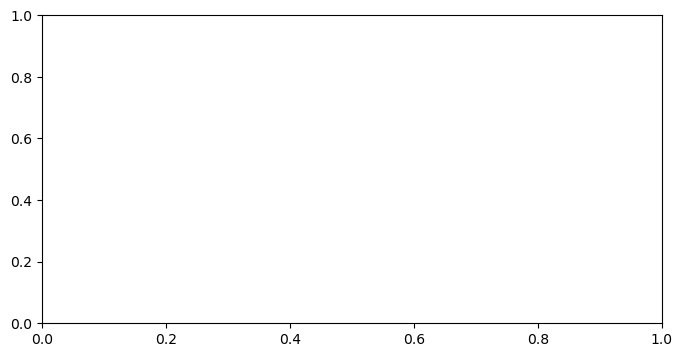

In [7]:
# Method 1: Create figure first, then add axes
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1)  # Add subplot: (rows, cols, position)
print(f"Created axes: {ax}")
print(f"Figure now has {len(fig.axes)} axes")

**Better approach:** Use `plt.subplots()` to create Figure and Axes together:

Created figure with 4 axes
Axes array shape: (2, 2)
Access top-left axes: Axes(0.125,0.53;0.352273x0.35)


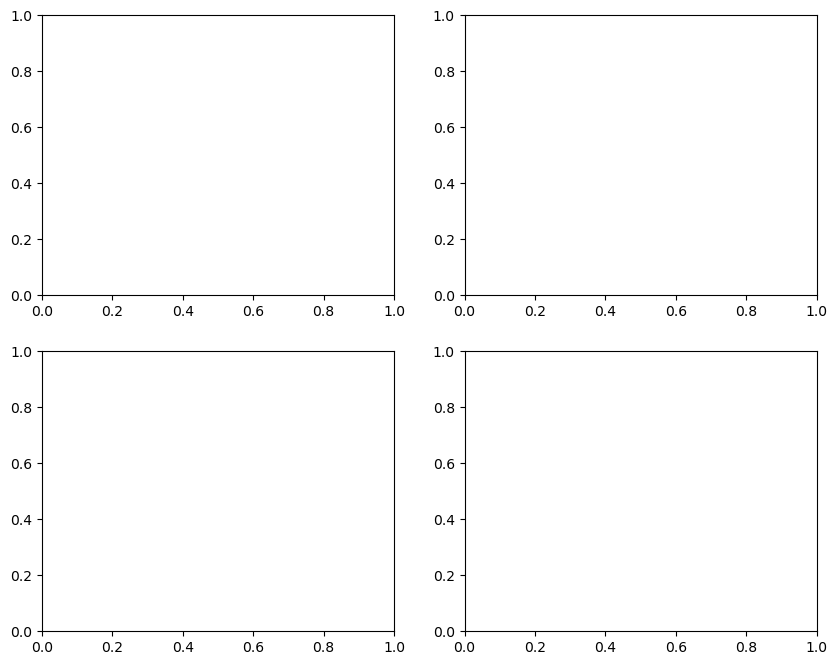

In [8]:
# Method 2: Create figure and axes in one step (RECOMMENDED)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
print(f"Created figure with {len(fig.axes)} axes")
print(f"Axes array shape: {axes.shape}")
print(f"Access top-left axes: {axes[0, 0]}")

**Note:** When you create a 2x2 grid with `subplots(2, 2)`, you get a 2D array of Axes objects. You access them using indexing: `axes[row, col]`.



### Create and Customize Plots with the OOP Interface

Now that we understand the hierarchy, let's create a complete plot using the OOP interface, customizing every component.

#### Components of an Axes Object

The `Axes` object contains several elements that make up the plot:

* **Data plotting area:** Contains the actual data visualizations (lines, bars, points, etc.)
* **X-axis and Y-axis:** Controls axis limits, labels, and ticks
* **Title and Labels:** The overall title and labels for each axis
* **Gridlines:** Optional lines to help align data visually
* **Spines:** The borders around the plot
* **Legend:** Explains what different data series represent
* **Annotations:** Text or arrows highlighting points of interest

Let's create a fully customized plot demonstrating all these components:

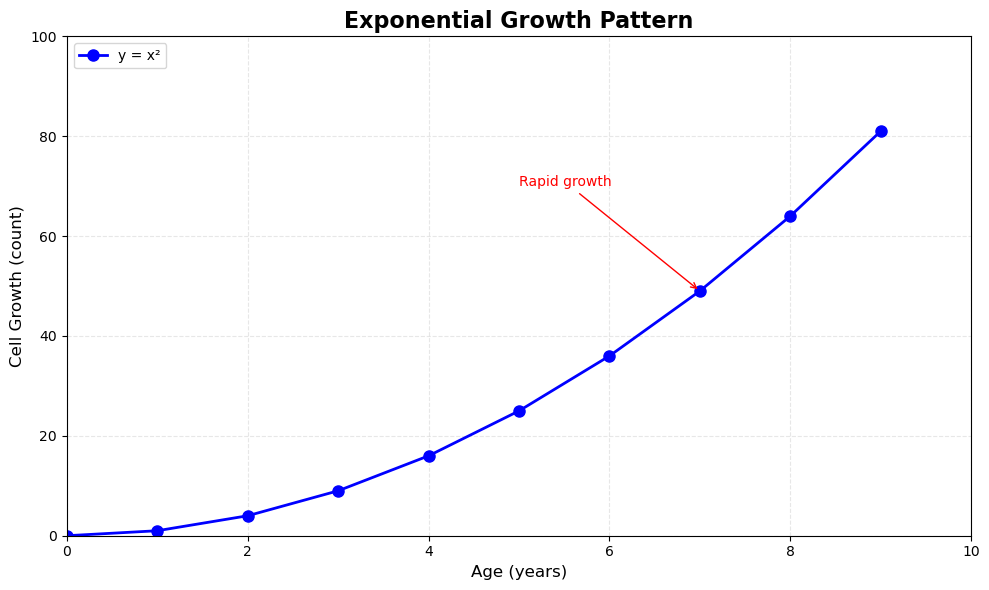

In [9]:
# Create sample data
x = np.arange(10)
y = x**2 

# Step 1: Create figure and axes
fig, ax = plt.subplots(1, 1, figsize=(10, 6)) 

# Step 2: Plot the data
ax.plot(x, y, color='blue', linewidth=2, marker='o', markersize=8, label='y = x²')

# Step 3: Set title and labels
ax.set_title("Exponential Growth Pattern", fontsize=16, fontweight='bold')
ax.set_xlabel("Age (years)", fontsize=12)
ax.set_ylabel("Cell Growth (count)", fontsize=12)

# Step 4: Set axis limits
ax.set_xlim([0, 10])
ax.set_ylim([0, 100])

# Step 5: Customize ticks
ax.set_xticks(range(0, 11, 2))
ax.set_yticks(range(0, 101, 20))

# Step 6: Add grid for readability
ax.grid(True, alpha=0.3, linestyle='--')

# Step 7: Add legend
ax.legend(loc="upper left", frameon=True)

# Step 8: Add annotation
ax.annotate('Rapid growth', xy=(7, 49), xytext=(5, 70),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

plt.tight_layout()
plt.show()

**Key Observations:**

Notice the pattern in the OOP interface - every customization method starts with `ax.set_*()` or acts on the axes object:

- `ax.set_title()` - sets title
- `ax.set_xlabel()` / `ax.set_ylabel()` - sets labels
- `ax.set_xlim()` / `ax.set_ylim()` - sets axis limits
- `ax.set_xticks()` / `ax.set_yticks()` - sets tick positions
- `ax.grid()` - adds gridlines
- `ax.legend()` - adds legend
- `ax.annotate()` - adds annotations

This explicit control is what makes the OOP interface powerful for complex visualizations.

## Mastering Subplots

Now that you understand matplotlib's architecture, let's explore how to create sophisticated multi-panel layouts. Subplots allow you to display multiple related visualizations in a single figure, making comparisons easier and creating comprehensive data stories.

The OOP interface truly shines when you need to work with multiple plots or integrate with other libraries. Here's why it's essential:

### Types of Subplot Layouts

We'll cover two main scenarios:

1. **Non-overlapping subplots** - Multiple plots in a grid (most common)
2. **Nested subplots** - Plots inside other plots (for insets and zoomed views)



### Create Simple Subplot Grids

The most common use case is arranging multiple plots in a grid pattern. The `plt.subplots()` function makes this straightforward.

**Syntax:**
```python
fig, axes = plt.subplots(nrows, ncols, figsize=(width, height))
```

Let's create a 2x2 grid and understand how to access individual subplots:

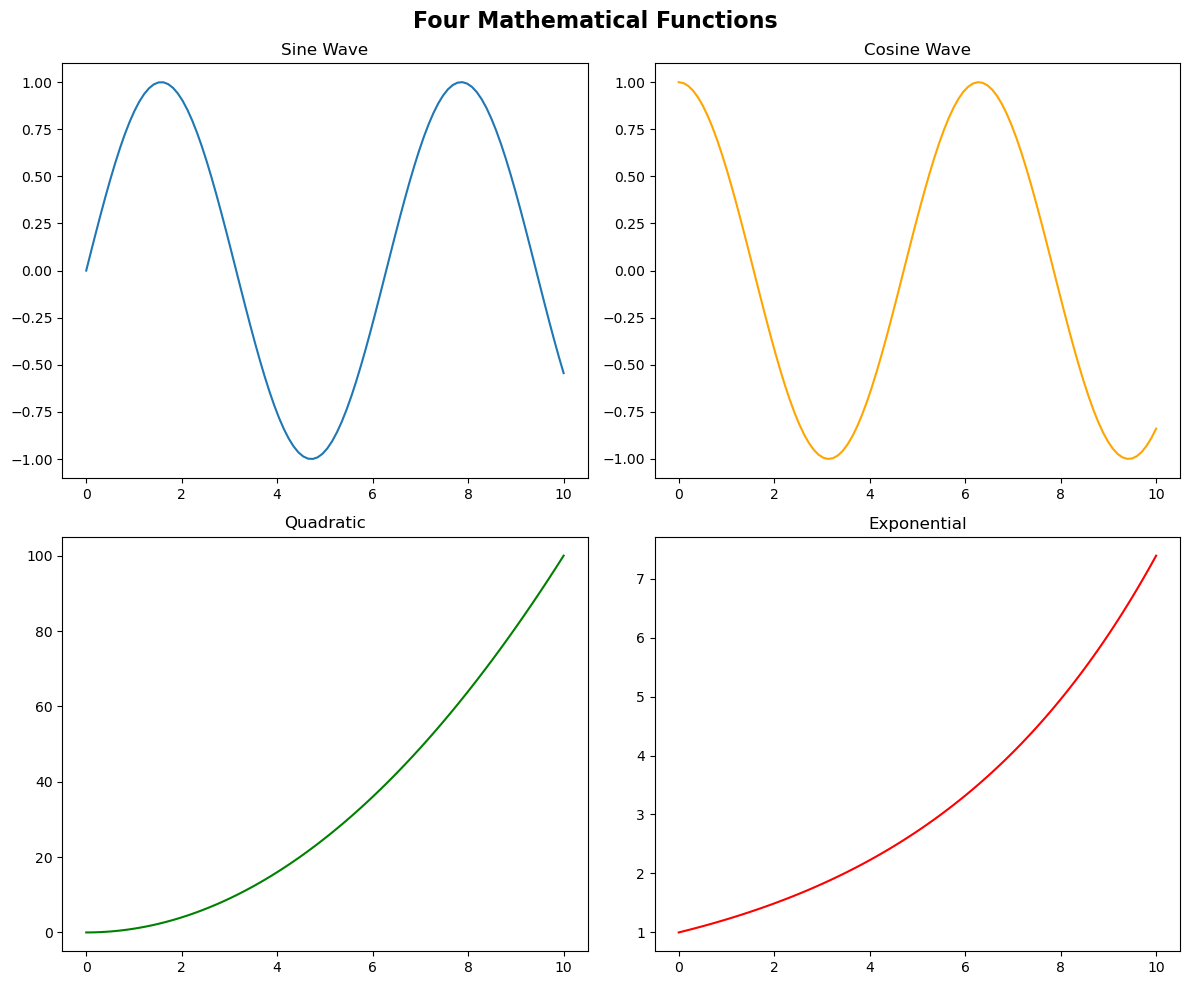

In [10]:
# Create a simple 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Create sample data
x = np.linspace(0, 10, 100)

# Plot in each subplot using array indexing
axes[0, 0].plot(x, np.sin(x))
axes[0, 0].set_title('Sine Wave')

axes[0, 1].plot(x, np.cos(x), color='orange')
axes[0, 1].set_title('Cosine Wave')

axes[1, 0].plot(x, x**2, color='green')
axes[1, 0].set_title('Quadratic')

axes[1, 1].plot(x, np.exp(x/5), color='red')
axes[1, 1].set_title('Exponential')

# Add a main title for the entire figure
fig.suptitle('Four Mathematical Functions', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**Key Points:**

- `axes` is a 2D NumPy array with shape `(2, 2)`
- Access subplots using `axes[row, col]` (0-indexed)
- Each axes is independent - customize titles, labels, colors separately
- `fig.suptitle()` adds a title for the entire figure (not just one subplot)
- `plt.tight_layout()` automatically adjusts spacing to prevent overlaps



### Control Subplot Layout and Spacing

Proper spacing between subplots is crucial for readability. Let's explore layout control options.

**Layout Control Methods:**

- `plt.tight_layout()` - Automatic spacing adjustment (recommended)
- `plt.tight_layout(pad=value)` - Control padding between subplots
- `plt.subplots_adjust()` - Manual control over spacing
- `figsize` parameter - Control overall figure dimensions



### Integrate Matplotlib with Pandas and Seaborn

One of the most powerful features of the OOP interface is the ability to pass axes objects to pandas and seaborn plotting functions. This gives you precise control over where each plot appears.

**The `ax` Parameter:**

Both pandas and seaborn plotting functions accept an `ax` parameter:

- `df.plot(..., ax=axes[0, 0])` - pandas plots
- `sns.scatterplot(..., ax=axes[0, 1])` - seaborn plots

This allows you to:

- Combine different plot types in one figure
- Mix pandas, seaborn, and matplotlib plotting
- Create complex dashboards with precise layout control

Let's create a comprehensive visualization using multiple data sources and libraries:

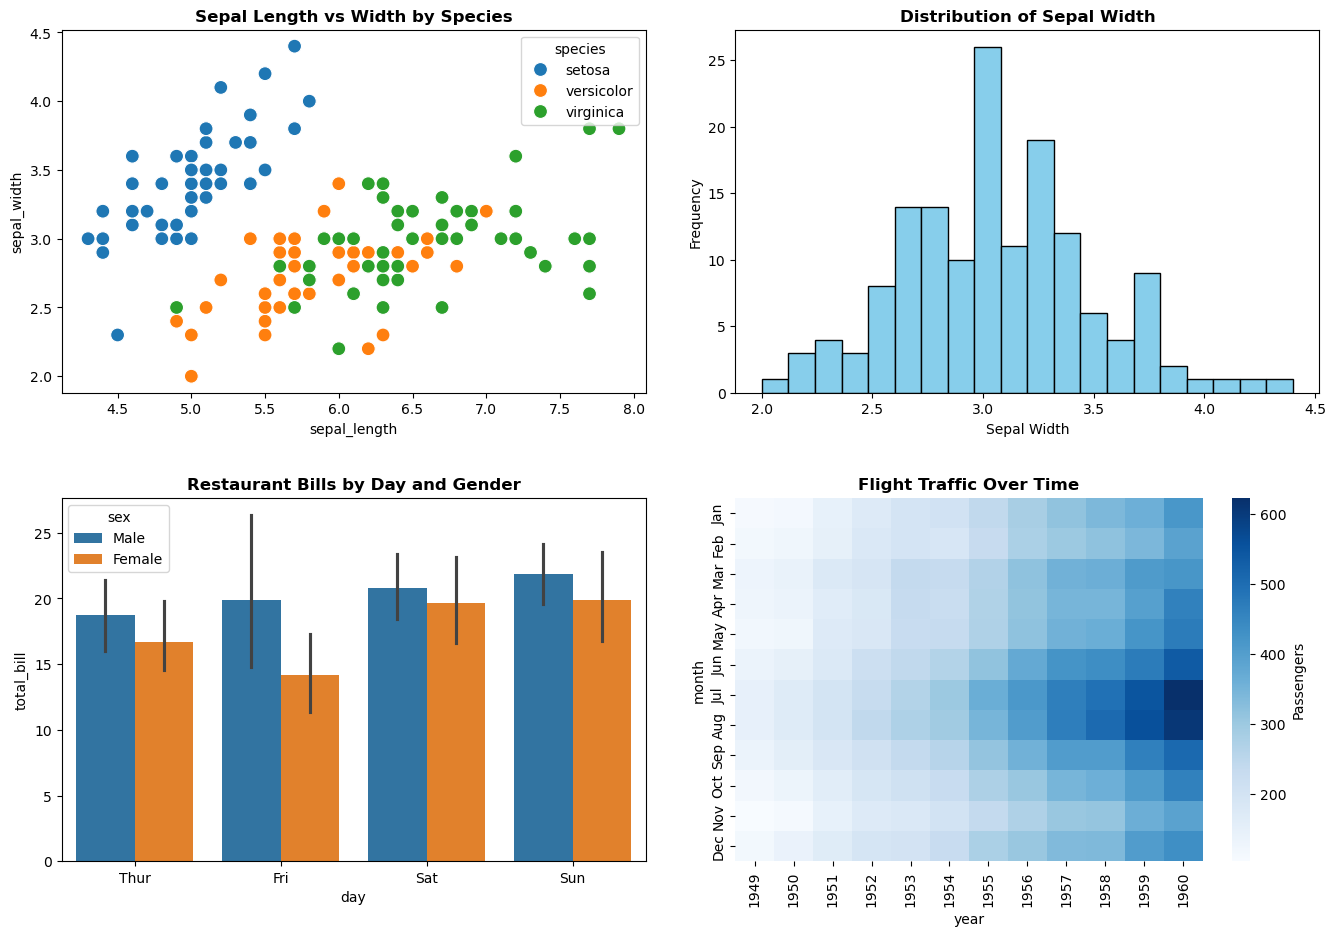

In [11]:
# Load datasets
flowers_df = sns.load_dataset('iris')
tips_df = sns.load_dataset('tips')
flights_df = sns.load_dataset("flights").pivot(index="month", columns="year", values="passengers")

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subplot 1: Seaborn scatter plot
axes[0, 0].set_title('Sepal Length vs Width by Species', fontsize=12, fontweight='bold')
sns.scatterplot(
    data=flowers_df, 
    x='sepal_length', 
    y='sepal_width', 
    hue='species', 
    s=100, 
    ax=axes[0, 0]
)

# Subplot 2: Pandas histogram
axes[0, 1].set_title('Distribution of Sepal Width', fontsize=12, fontweight='bold')
flowers_df['sepal_width'].plot.hist(bins=20, ax=axes[0, 1], color='skyblue', edgecolor='black')
axes[0, 1].set_xlabel('Sepal Width')
axes[0, 1].set_ylabel('Frequency')

# Subplot 3: Seaborn bar plot
axes[1, 0].set_title('Restaurant Bills by Day and Gender', fontsize=12, fontweight='bold')
sns.barplot(
    data=tips_df, 
    x='day', 
    y='total_bill', 
    hue='sex', 
    ax=axes[1, 0]
)

# Subplot 4: Seaborn heatmap
axes[1, 1].set_title('Flight Traffic Over Time', fontsize=12, fontweight='bold')
sns.heatmap(flights_df, cmap='Blues', ax=axes[1, 1], cbar_kws={'label': 'Passengers'})

# Adjust layout with custom padding
plt.tight_layout(pad=3)
plt.show()

**Key Observations:**

1. **Mixed Libraries:** We seamlessly combined seaborn scatter plots, pandas histograms, seaborn bar plots, and seaborn heatmaps
2. **The `ax` Parameter:** Every plotting function received a specific axes object (`ax=axes[row, col]`)
3. **Independent Customization:** Each subplot has its own title, labels, and styling
4. **Layout Control:** `tight_layout(pad=3)` adds extra padding for readability

**Important Notes:**

- Seaborn and pandas are wrappers around matplotlib
- They create plots ON the axes you specify via the `ax` parameter
- Without the `ax` parameter, they would create their own figure/axes
- This is why the OOP interface is essential for complex layouts



### Create Nested Subplots (Insets)

Sometimes you want to show a detailed view of a specific region within a larger plot. This is called an **inset** or **nested subplot**.

**Use Cases for Insets:**

- Zooming into a specific region of interest
- Showing a histogram or distribution alongside the main plot
- Displaying summary statistics or related analysis
- Creating "picture-in-picture" visualizations

You can create nested subplots using `fig.add_axes()` or `inset_axes()`.

#### Using `add_axes()` for Precise Control

**Syntax:**
```python
ax = fig.add_axes([left, bottom, width, height])
```

**Parameters (all are fractions from 0 to 1):**

- `left`: Horizontal starting position (0=left edge, 1=right edge)
- `bottom`: Vertical starting position (0=bottom edge, 1=top edge)
- `width`: Width as fraction of figure width
- `height`: Height as fraction of figure height

Let's create a plot with two inset plots showing related information:

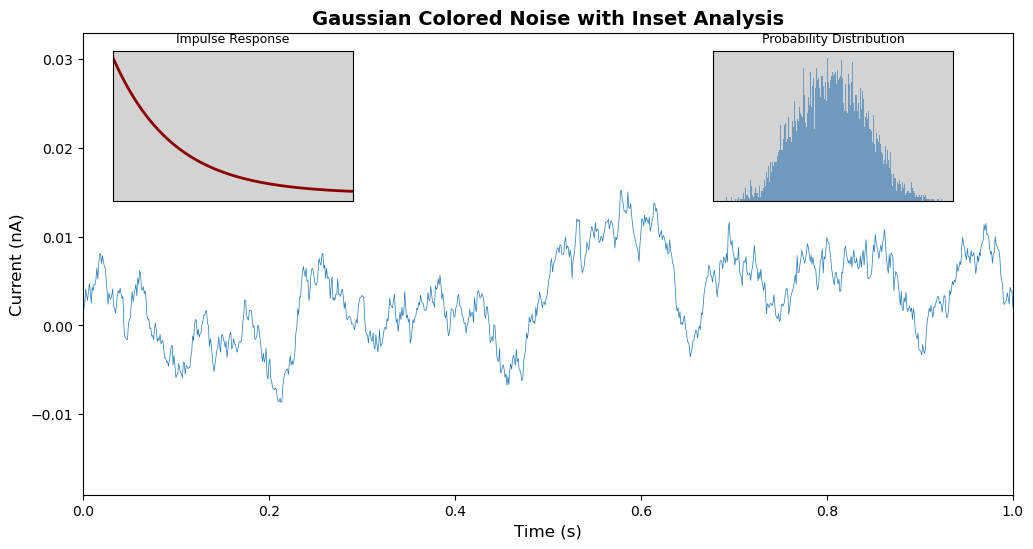

In [12]:
# Set random seed for reproducibility
np.random.seed(19680801)

# Create colored noise data
dt = 0.001
t = np.arange(0.0, 10.0, dt)
r = np.exp(-t[:1000] / 0.05)  # Impulse response
x = np.random.randn(len(t))
s = np.convolve(x, r)[:len(x)] * dt  # Colored noise

# Create the main figure and axes
fig, main_ax = plt.subplots(figsize=(12, 6))

# Plot main data
main_ax.plot(t, s, linewidth=0.5)
main_ax.set_xlim(0, 1)
main_ax.set_ylim(1.1 * np.min(s), 2 * np.max(s))
main_ax.set_xlabel('Time (s)', fontsize=12)
main_ax.set_ylabel('Current (nA)', fontsize=12)
main_ax.set_title('Gaussian Colored Noise with Inset Analysis', fontsize=14, fontweight='bold')

# Create right inset showing probability distribution
# [left, bottom, width, height] as fractions of figure
right_inset_ax = fig.add_axes([0.65, 0.6, 0.2, 0.25], facecolor='lightgray')
right_inset_ax.hist(s, 400, density=True, color='steelblue', alpha=0.7)
right_inset_ax.set_title('Probability Distribution', fontsize=9)
right_inset_ax.set_xticks([])
right_inset_ax.set_yticks([])

# Create left inset showing impulse response
left_inset_ax = fig.add_axes([0.15, 0.6, 0.2, 0.25], facecolor='lightgray')
left_inset_ax.plot(t[:len(r)], r, color='darkred', linewidth=2)
left_inset_ax.set_title('Impulse Response', fontsize=9)
left_inset_ax.set_xlim(0, 0.2)
left_inset_ax.set_xticks([])
left_inset_ax.set_yticks([])

plt.show()

**Understanding the Inset Positions:**

1. **Right Inset** `[0.65, 0.6, 0.2, 0.25]`:
   - Starts 65% from left edge
   - Starts 60% from bottom edge
   - Width is 20% of figure width
   - Height is 25% of figure height

2. **Left Inset** `[0.15, 0.6, 0.2, 0.25]`:
   - Starts 15% from left edge
   - Same vertical position and size as right inset

**Tips for Insets:**

- Use `facecolor` to distinguish insets from main plot
- Remove ticks (`set_xticks([])`) to reduce clutter
- Keep inset titles short and informative
- Position insets where they don't obscure important data
- Consider using `inset_axes()` from `mpl_toolkits.axes_grid1` for more flexible positioning



### Advanced Formatting with Custom Tick Formatters

When creating professional visualizations, you often need to format axis labels for readability. This is especially important for:


- Large numbers (adding commas or using K/M notation)
- Currency values (adding $ or other symbols)
- Percentages
- Dates and times
- Scientific notation

The OOP interface provides powerful formatting capabilities through the `yaxis` and `xaxis` objects.

#### Example: Formatting Large Numbers with Commas

Let's visualize noise complaint data with properly formatted axis labels:

In [13]:
# Load noise complaint data
nyc_party_complaints = pd.read_csv('datasets/party_nyc.csv')
nyc_party_complaints.head()

,Created Date,Closed Date,Location Type,Incident Zip,City,Borough,Latitude,Longitude,Hour_of_the_day,Month_of_the_year
0,12/31/2015 0:01,12/31/2015 3:48,Store/Commercial,10034.0,NEW YORK,MANHATTAN,40.866183,-73.918930,0,12
1,12/31/2015 0:02,12/31/2015 4:36,Store/Commercial,10040.0,NEW YORK,MANHATTAN,40.859324,-73.931237,0,12
2,12/31/2015 0:03,12/31/2015 0:40,Residential Building/House,10026.0,NEW YORK,MANHATTAN,40.799415,-73.953371,0,12
3,12/31/2015 0:03,12/31/2015 1:53,Residential Building/House,11231.0,BROOKLYN,BROOKLYN,40.678285,-73.994668,0,12
4,12/31/2015 0:05,12/31/2015 3:49,Residential Building/House,10033.0,NEW YORK,MANHATTAN,40.850304,-73.938516,0,12


Now let's create a bar plot showing complaint locations, with properly formatted y-axis labels:

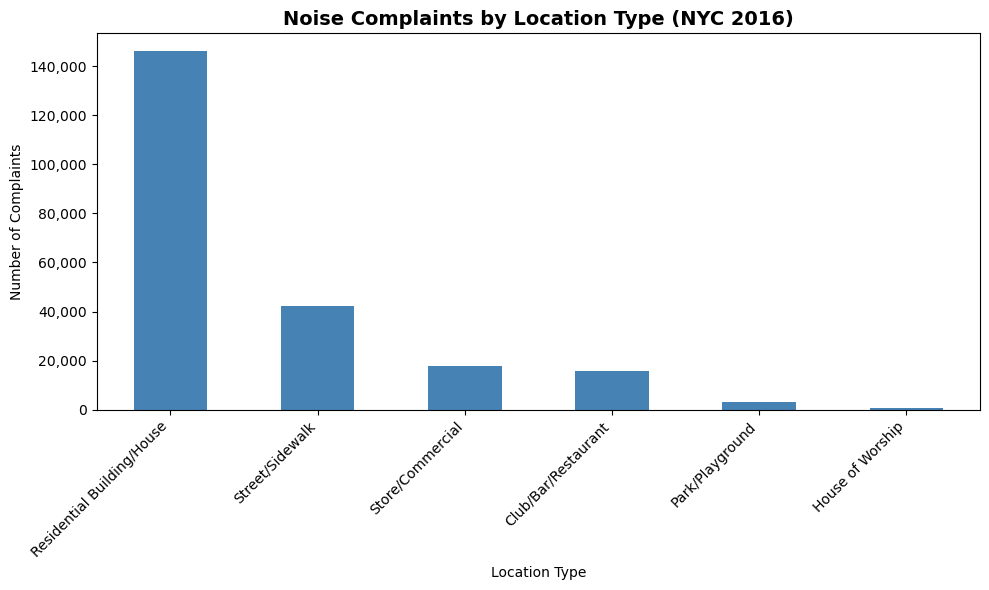

In [14]:
# Create bar plot using pandas (returns axes object)
ax = nyc_party_complaints['Location Type'].value_counts().plot.bar(
    ylabel='Number of Complaints',
    xlabel='Location Type',
    figsize=(10, 6),
    color='steelblue'
)

# Format y-axis to add commas to large numbers
ax.yaxis.set_major_formatter('{x:,.0f}')

# Customize the plot
ax.set_title('Noise Complaints by Location Type (NYC 2016)', fontsize=14, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**Key Technique - Custom Axis Formatting:**

```python
ax.yaxis.set_major_formatter('{x:,.0f}')
```

This uses Python's format specification mini-language:

- `{x:,.0f}` - Format as float with comma separators and 0 decimal places
- `{x:,.2f}` - Two decimal places with commas
- `{x:.2%}` - Percentage with 2 decimal places
- `${x:,.0f}` - Currency format

**Observations:**

- Most complaints come from residential buildings and houses (as expected for party/music noise)
- The y-axis now shows "1,000" instead of "1000" - much easier to read!
- Pandas `.plot.bar()` returns an axes object that we can further customize
- We rotated x-axis labels 45° for better readability using `set_xticklabels()`

This demonstrates how pandas plotting (convenience) and matplotlib OOP (control) work together seamlessly.




## Creating Subplots with Seaborn

We previously demonstrated how Seaborn integrates seamlessly with Matplotlib’s object-oriented interface, allowing you to pass the `ax` argument to any Seaborn function, thereby directing the plot to a specific axis within a subplot grid.

Additionally, Seaborn offers a more convenient and simplified approach to creating subplots, thanks to its high-level functions and built-in integration with Matplotlib. Here’s how Seaborn makes working with subplots easier:

### Using `Facetgrid`

Seaborn's `FacetGrid` is a powerful tool for creating **small multiples** - grids of plots where each subplot shows a subset of your data based on categorical variables.

**Why Use FacetGrid?**

- Automatically creates subplot grids based on data categories
- Much easier than manually creating subplots and filtering data
- Ideal for comparing patterns across different groups
- Enables exploration of multi-dimensional relationships

**Key Parameters:**

- `data`: DataFrame to visualize
- `col`: Variable to create column-wise subplots
- `row`: Variable to create row-wise subplots
- `hue`: Variable for color-coding within each subplot
- `col_wrap`: Wrap columns after this many plots

Let's explore with the tips dataset:

In [15]:
# Seaborn Example using FacetGrid:
tips_df = sns.load_dataset("tips")
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


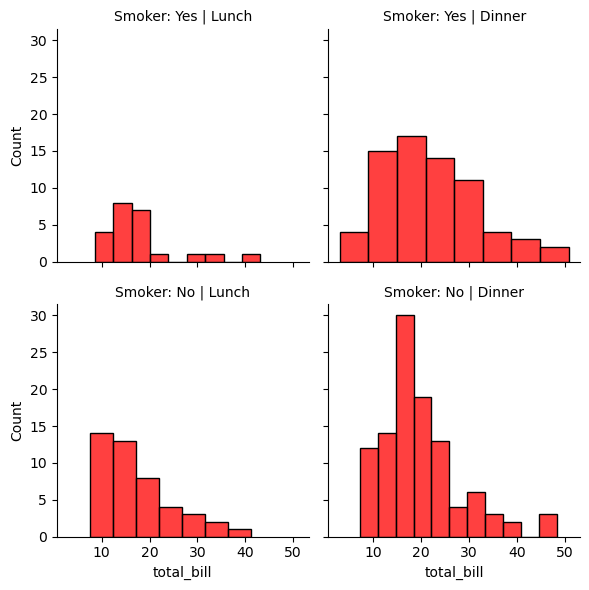

In [16]:
g = sns.FacetGrid(tips_df, col='time', row='smoker')
g.map(sns.histplot, 'total_bill', color='r')
g.set_titles(col_template="{col_name}", row_template="Smoker: {row_name}");

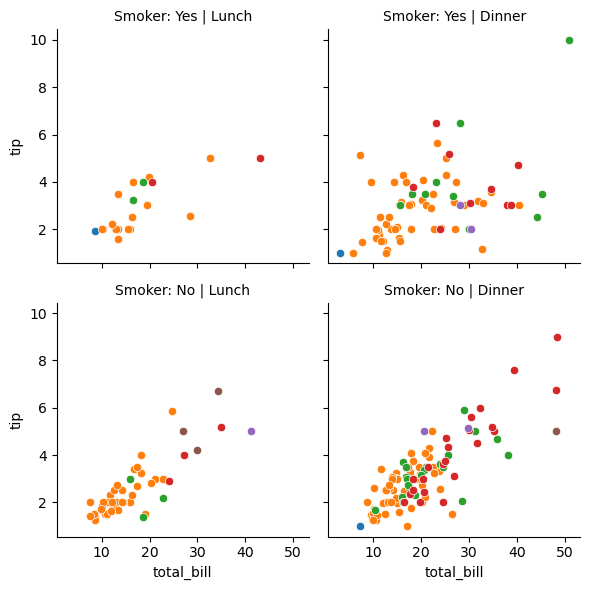

In [17]:
# adding hue to the FacetGrid
g = sns.FacetGrid(tips_df, col='time', row='smoker',hue='size')
# Plot a scatterplot of the total bill and tip for each combination of time and smoker
g.map(sns.scatterplot, 'total_bill', 'tip')
g.set_titles(col_template="{col_name}", row_template="Smoker: {row_name}");

### Using  `Pairplot`

Pairplots are used to visualize the association between all variable-pairs in the data. In other words, pairplots simultaneously visualize the scatterplots between all variable-pairs.

Let us visualize the pair-wise association of tips variables in the tips dataset

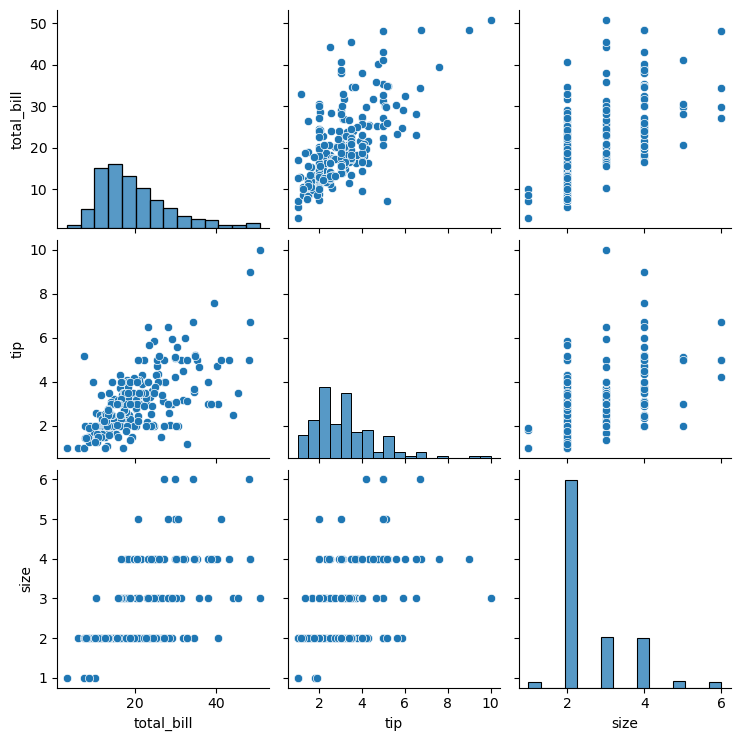

In [19]:
sns.pairplot(tips_df );

Let us visualize the pair-wise association of nutrition variables in the starbucks drinks data.

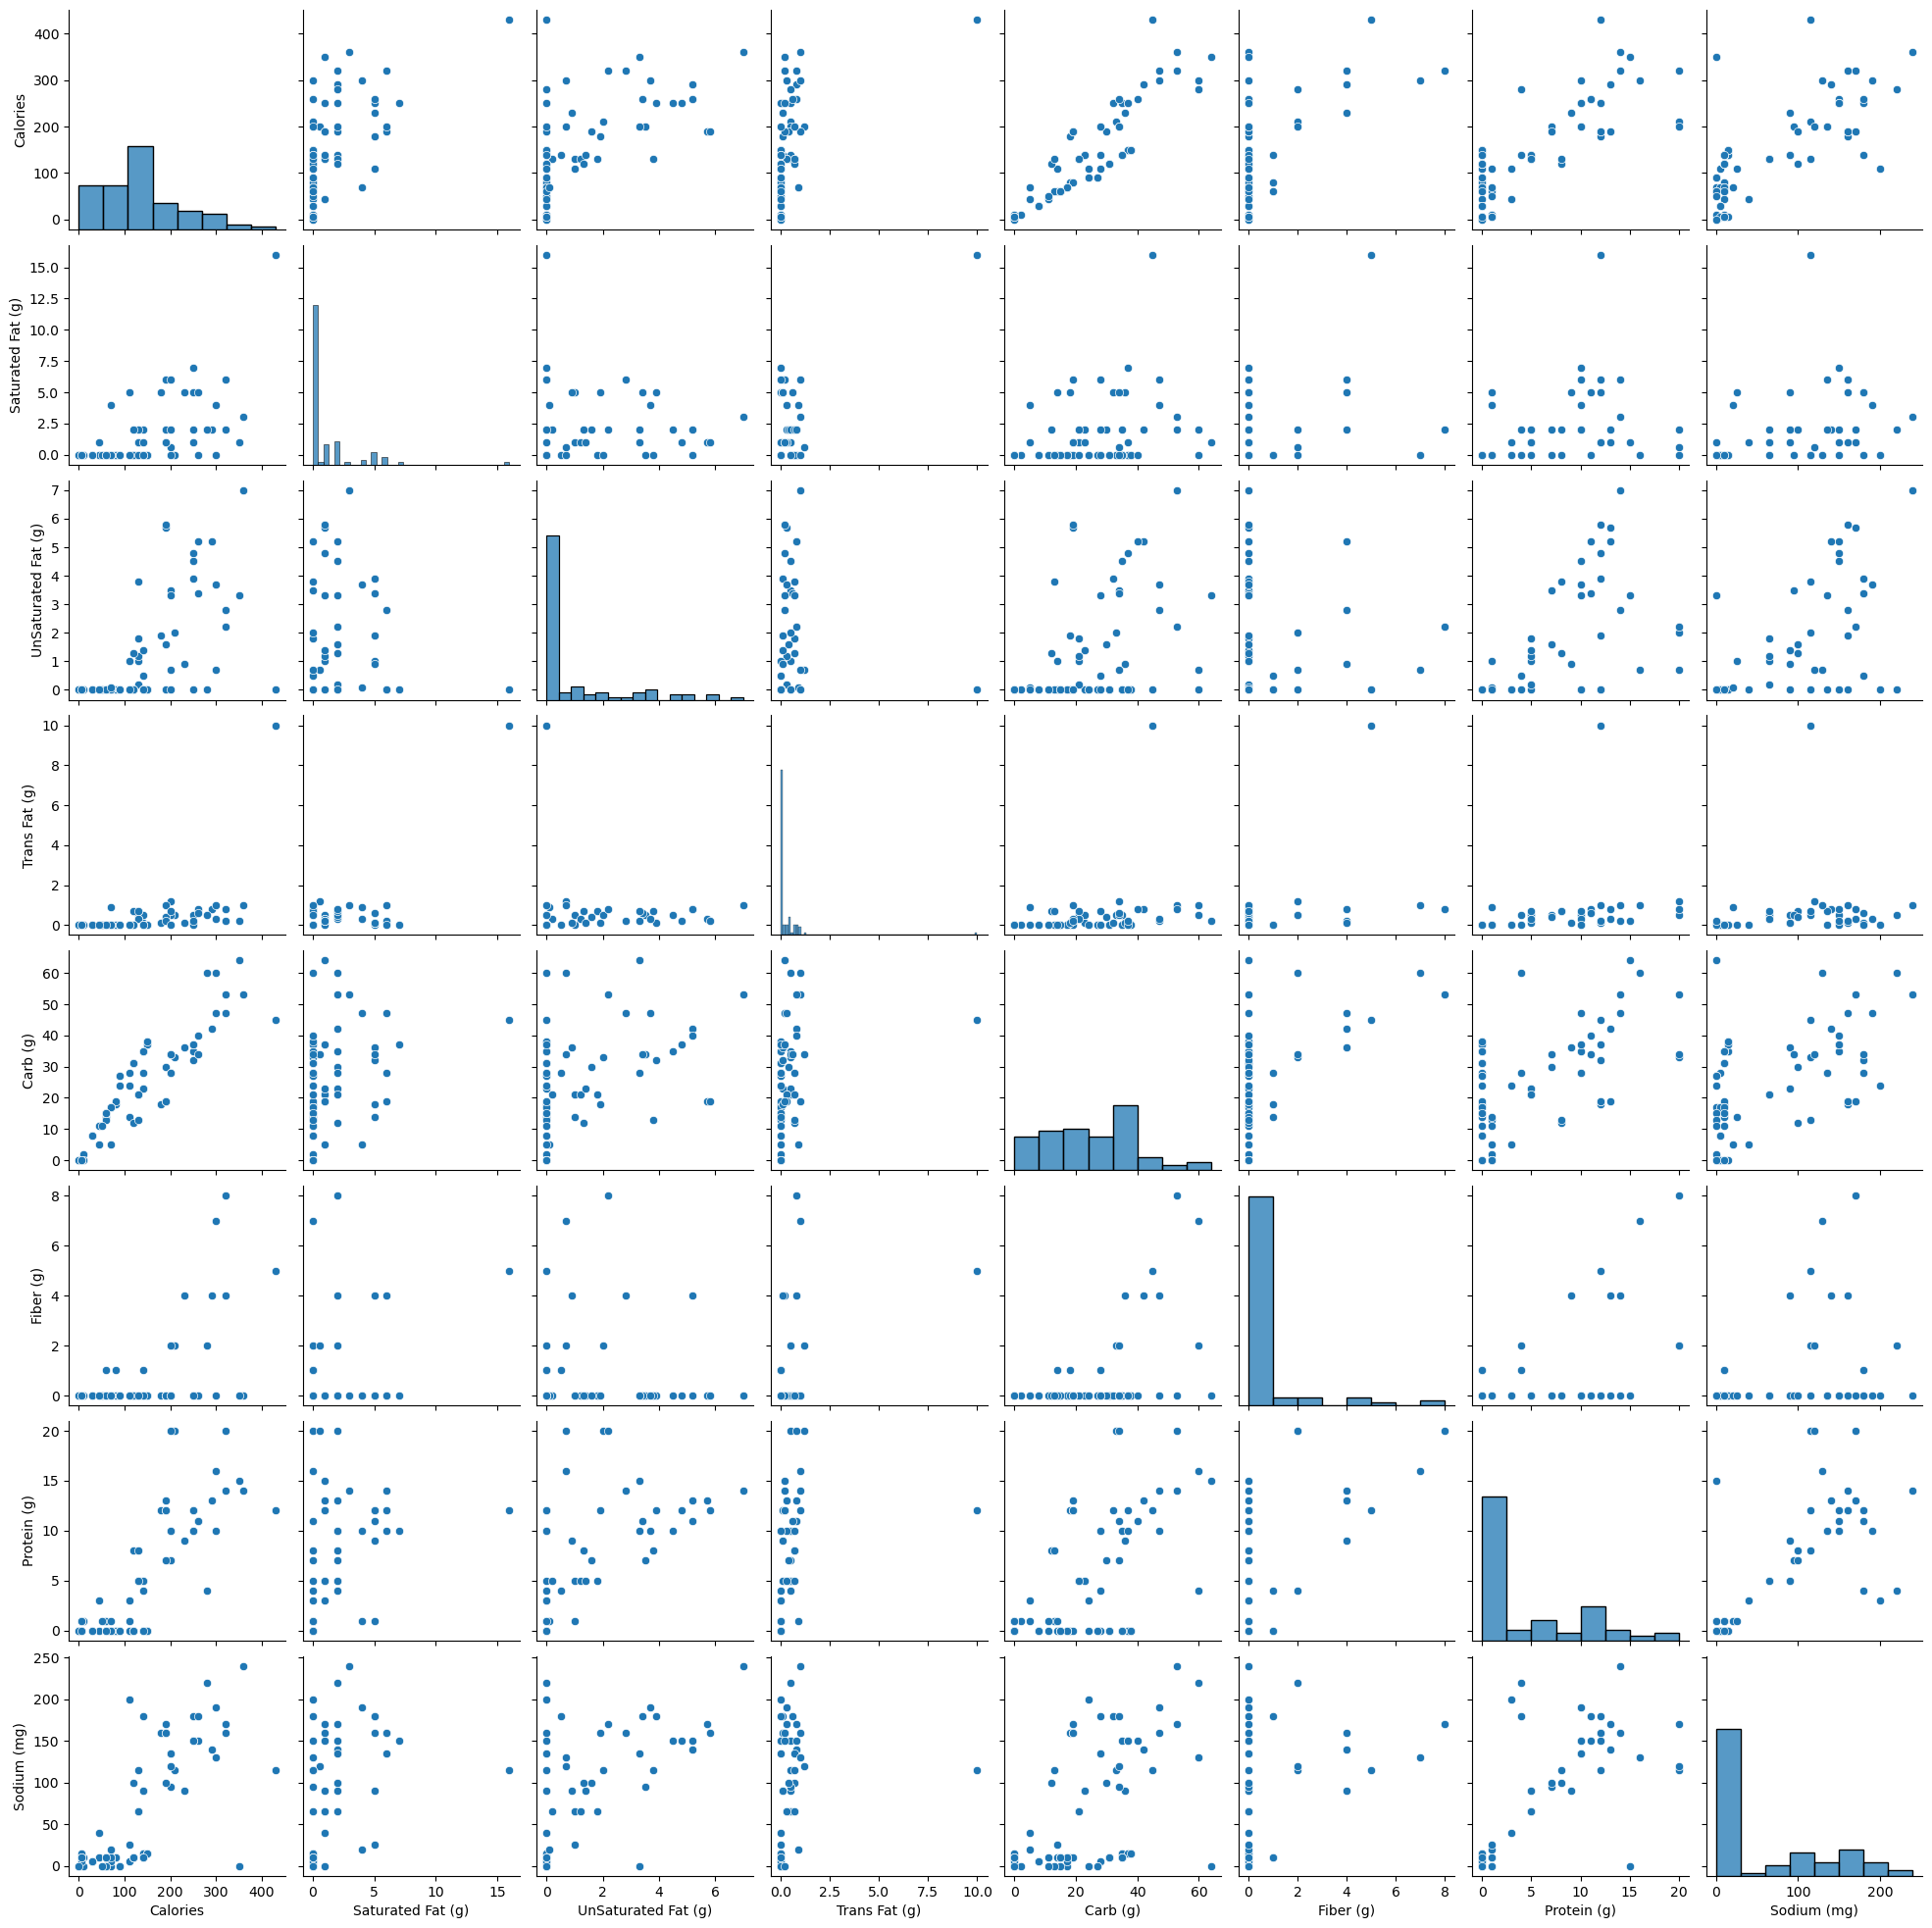

In [20]:
starbucks_drinks = pd.read_csv('datasets/starbucks-menu-nutrition-drinks.csv')
sns.pairplot(starbucks_drinks);

In the above pairplot, note that:

* The histograms on the diagonal of the grid show the distribution of each of the variables.
* Instead of a histogram, we can visualize the density plot with the argument kde = True.
* The scatterplots in the rest of the grid are the pair-wise plots of all the variables.

## Geosptial Plotting

There are several widely used Python packages pecifically designed for working with geospatial datasets. In this lesson, we will cover:

* GeoPandas
* Folium

Let's import them

In [22]:
import warnings

# Suppress all non-critical warnings
warnings.filterwarnings("ignore")
import geopandas as gpd
import geopandas 
import folium
import geodatasets

### Static Plots with GeoPandas

A **shapefile** is a widely-used format for storing geographic information system (GIS) data, specifically vector data. It contains geometries (like points, lines, and polygons) that represent features on the earth's surface, along with associated attributes for each feature, such as names, populations, or other data relevant to the feature.

#### Components of a Shapefile

A shapefile isn’t a single file but a collection of files with the same name and different extensions, which work together to store geographic and attribute data:

* `.shp`: Stores the geometry (shapes of features, like points, lines, polygons).
* `.shx`: Contains an index to quickly access geometries in the .shp file.
* `.dbf`: A table storing attributes associated with each feature.

There may also be other optional files (e.g., .prj for projection information).

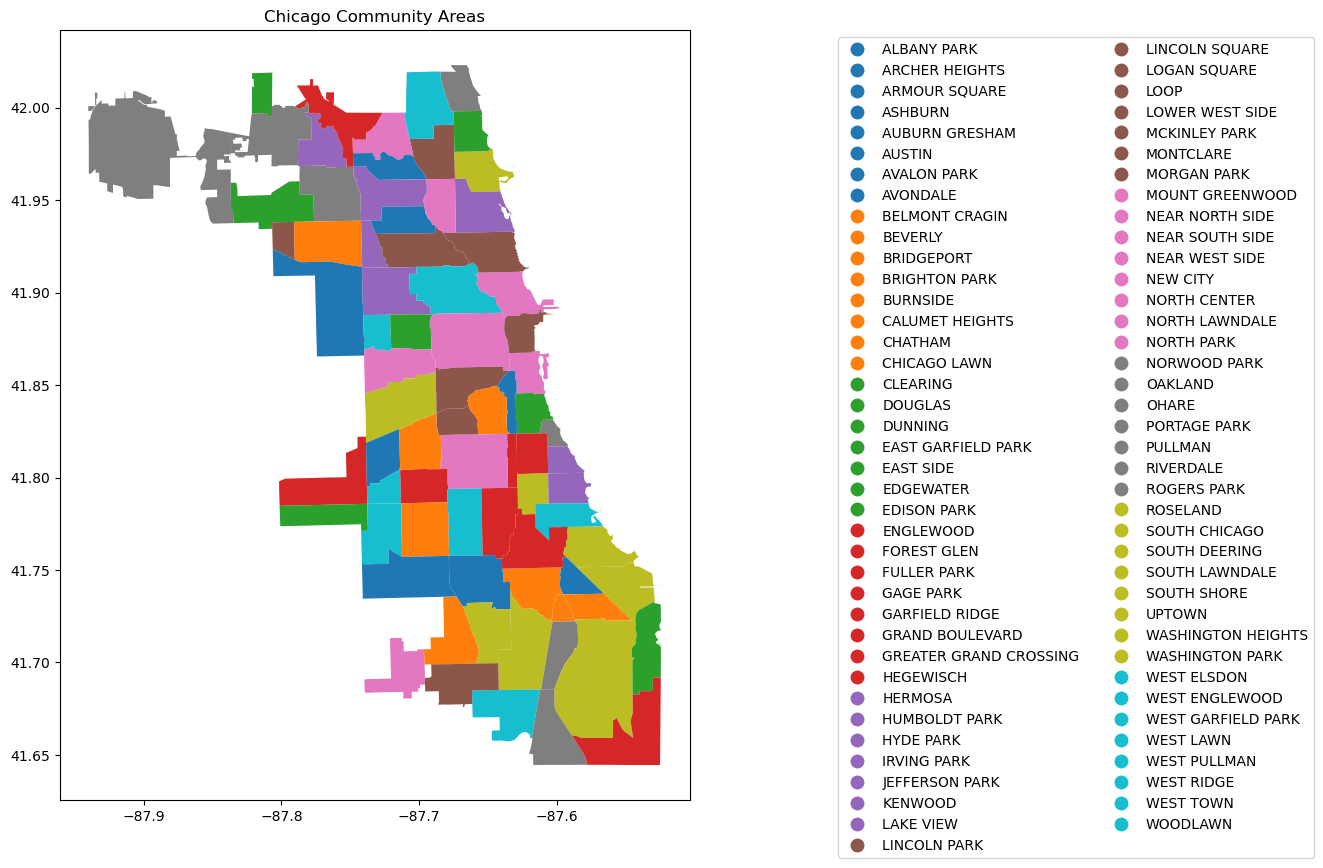

In [23]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 10))

# Plot your GeoDataFrame
chicago = gpd.read_file(r'datasets/chicago_boundaries\geo_export_26bce2f2-c163-42a9-9329-9ca6e082c5e9.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

# Add title (optional)
plt.title('Chicago Community Areas');


Let's print out the information in the shapefile

In [24]:
chicago.head()

,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len,geometry
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


In [25]:
chicago['geometry'].head()

0    POLYGON ((-87.60914 41.84469, -87.60915 41.844...
1    POLYGON ((-87.59215 41.81693, -87.59231 41.816...
2    POLYGON ((-87.6288 41.80189, -87.62879 41.8017...
3    POLYGON ((-87.60671 41.81681, -87.6067 41.8165...
4    POLYGON ((-87.59215 41.81693, -87.59215 41.816...
Name: geometry, dtype: geometry

In [26]:
# Check the column names to see available data fields
print("Columns in the shapefile:", chicago.columns)

# Check the data types of each column
print("Data types:", chicago.dtypes)

# View the spatial extent (bounding box) of the shapes
print("Bounding box:", chicago.total_bounds)

# Check the coordinate reference system (CRS)
print("CRS:", chicago.crs)

Columns in the shapefile: Index(['area', 'area_num_1', 'area_numbe', 'comarea', 'comarea_id',
       'community', 'perimeter', 'shape_area', 'shape_len', 'geometry'],
      dtype='object')
Data types: area           float64
area_num_1      object
area_numbe      object
comarea        float64
comarea_id     float64
community       object
perimeter      float64
shape_area     float64
shape_len      float64
geometry      geometry
dtype: object
Bounding box: [-87.94011408  41.64454312 -87.5241371   42.02303859]
CRS: EPSG:4326


To enhance the geospatial plot, we’ll use the shapefile as a background to provide context for Chicago’s community areas. On top of that, we'll layer points of interest, such as restaurants, and shops, to illustrate the city’s amenities. This approach will make the map more informative and visually engaging, with community boundaries as the foundation and key locations overlayed to highlight areas of interest.

Next, we will add the Divvy bicycle stations on top of the chicago shapefile

### Dataset: Bicycle Sharing in Chicago


<p align="center">
  <img src="https://d21xlh2maitm24.cloudfront.net/chi/DivvyLogo_p_v2.svg?mtime=20170608140727"/>
</p>

Divvy is Chicagoland’s bike share system (in collaboration with Chicago Department of Transportation), with 6,000 bikes available at 570+ stations across Chicago and Evanston. Divvy provides residents and visitors with a convenient, fun and affordable transportation option for getting around and exploring Chicago.

Divvy, like other bike share systems, consists of a fleet of specially designed, sturdy and durable bikes that are locked into a network of docking stations throughout the region. The bikes can be unlocked from one station and returned to any other station in the system. People use bike share to explore Chicago, commute to work or school, run errands, get to appointments or social engagements, and more.

Divvy is available for use 24 hours/day, 7 days/week, 365 days/year, and riders have access to all bikes and stations across the system.

We will be using divvy trips in the year of 2013

In [27]:
# read the csv file'divvy_2013.csv' into pandas pandas dataframe
data = pd.read_csv('datasets/divvy_2013.csv')
data.head()

,trip_id,usertype,gender,starttime,stoptime,tripduration,from_station_id,from_station_name,latitude_start,longitude_start,...,dewpoint,humidity,pressure,visibility,wind_speed,precipitation,events,rain,conditions,month
0,3940,Subscriber,Male,2013-06-27 01:06:00,2013-06-27 09:46:00,31177,91,Clinton St & Washington Blvd,41.88338,-87.641170,...,64.9,96.0,29.75,7.0,0.0,-9999.0,partlycloudy,0,Scattered Clouds,6
1,4095,Subscriber,Male,2013-06-27 12:06:00,2013-06-27 12:11:00,301,85,Michigan Ave & Oak St,41.90096,-87.623777,...,69.1,55.0,29.75,10.0,13.8,-9999.0,mostlycloudy,0,Mostly Cloudy,6
2,4113,Subscriber,Male,2013-06-27 11:09:00,2013-06-27 11:11:00,140,88,May St & Randolph St,41.88397,-87.655688,...,70.0,61.0,29.75,10.0,10.4,-9999.0,mostlycloudy,0,Mostly Cloudy,6
3,4118,Customer,NaN,2013-06-27 12:11:00,2013-06-27 12:16:00,316,85,Michigan Ave & Oak St,41.90096,-87.623777,...,69.1,55.0,29.75,10.0,13.8,-9999.0,mostlycloudy,0,Mostly Cloudy,6
4,4119,Subscriber,Male,2013-06-27 11:12:00,2013-06-27 11:13:00,87,88,May St & Randolph St,41.88397,-87.655688,...,70.0,61.0,29.75,10.0,10.4,-9999.0,mostlycloudy,0,Mostly Cloudy,6


In the Divvy dataset, each trip record includes the latitude and longitude coordinates of both the pickup and drop-off locations, which correspond to Divvy bike stations. These coordinates allow us to map the precise locations of each station, making it possible to visually display the network of Divvy stations across the city. By plotting these stations on a map, we can better understand the geographic distribution and accessibility of Divvy’s bike-sharing network.

Below are the basic data cleaning steps to extract the coordinates of the Divvy stations.

In [ ]:
# drop the duplicates in the column 'to_station_id', 'to_station_name', 'latitude_end', 'longitude_end'
# data_station_same = data[['from_station_id', 'from_station_name', 'latitude_start', 'longitude_start', 'to_station_id', 'to_station_name', 'latitude_end', 'longitude_end']].drop_duplicates()
# data_station_same.shape

### Adding the divvy station to the plot

Once the coordinates are prepared, we’ll add them as scatter plots on top of the Chicago shapefile

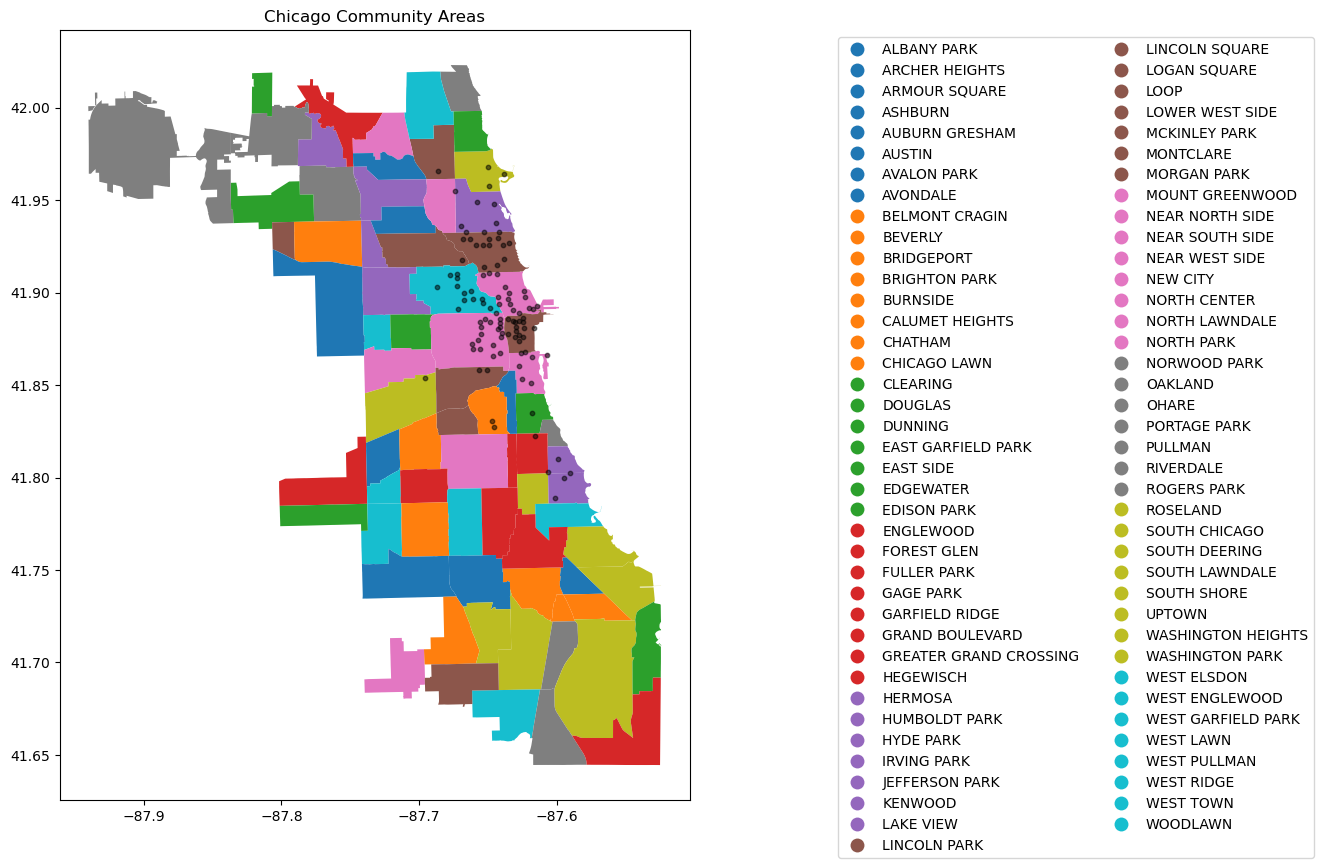

In [28]:
# Adding the stations to the plot
fig, ax = plt.subplots(figsize=(15, 10))

chicago = gpd.read_file(r'datasets/chicago_boundaries\geo_export_26bce2f2-c163-42a9-9329-9ca6e082c5e9.shp')
chicago.plot(column='community', ax=ax, legend=True, legend_kwds={'ncol': 2, 'bbox_to_anchor': (2, 1)})

# Plot the stations
longlat_df = data[[ 'latitude_start', 'longitude_start']].drop_duplicates()

plt.scatter(longlat_df['longitude_start'], longlat_df['latitude_start'], s=10, alpha=0.5, color='black', marker='o')


# Add title (optional)
plt.title('Chicago Community Areas');


### Change the chicago shapefile

Using a different Chicago shapefile from `GeoDa` is a great way to observe how geographic boundaries or data details may vary

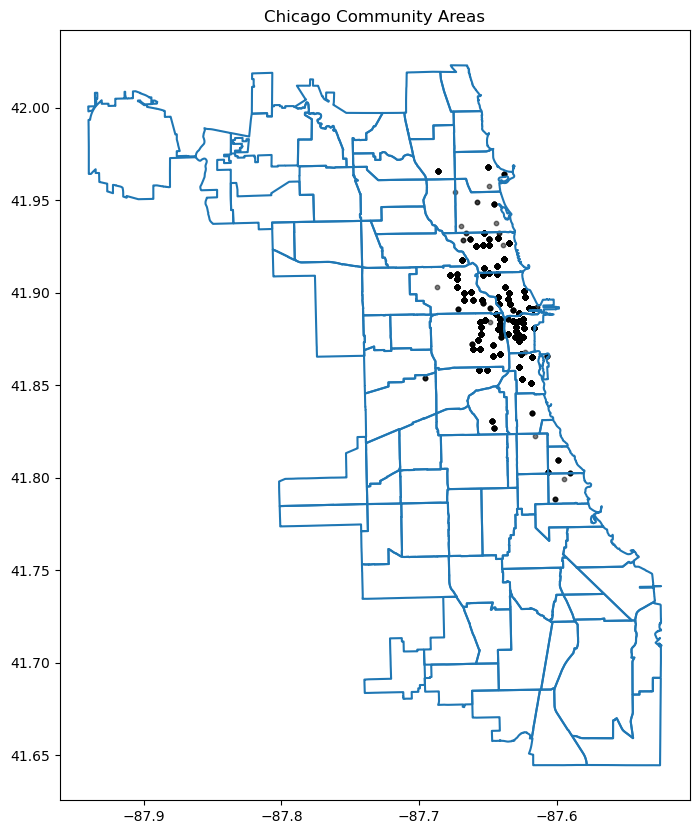

In [29]:
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

# Plot the data
fig, ax = plt.subplots(figsize=(15, 10))
chicago.boundary.plot(ax=ax)
plt.scatter(data['longitude_start'], data['latitude_start'], s=10, alpha=0.5, color='black', marker='o')
plt.title('Chicago Community Areas');

### Interactive Plotting 

Alongside static plots, `geopandas` can create interactive maps based on the [folium](https://python-visualization.github.io/folium/latest/) library.

Creating maps for interactive exploration mirrors the API of static [plots](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html) in an [explore()](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.explore.html) method of a GeoSeries or GeoDataFrame.

 Here’s an explanation of how `explore()` works and its key features:

Key Features of `explore()`:

1. Interactive Map Display:

   * When you call explore() on a Geodataframe (gdf), it launches an interactive map widget directly within your Jupyter notebook.
   * This map allows you to pan, zoom, and interact with the geometries (points, lines, polygons) in your Geodataframe.

2. Layer Control:

   * explore() automatically adds the geometries from your Geodataframe as layers on the map.
   * Each geometry type (points, lines, polygons) is displayed with appropriate styling and markers.

3. Tooltip Information:

   * When you hover over a geometry in the map, explore() displays tooltip information that typically includes attribute data associated with that geometry.
   * This feature is useful for inspecting specific details or properties of individual features in your geospatial dataset.

4. Search and Filter:

   * explore() provides basic search and filter functionalities directly on the map.
   * You can search for specific attribute values or filter the displayed features based on attribute criteria defined in your Geodataframe.

5. Customization:

   * Although explore() provides default styling and interaction behaviors, you can customize the map further using parameters or by manipulating the Geodataframe before calling explore().

In [34]:
# use the geopandas explore default settings
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))
m = chicago.explore()
display(m)

Adding the population layer

In [35]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
# Customerize the explore settings
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

m = chicago.explore(
    column="POP2010",  # make choropleth based on "POP2010" column
    scheme="naturalbreaks",  # use mapclassify's natural breaks scheme
    legend=True,  # show legend
    k=10,  # use 10 bins
    tooltip=False,  # hide tooltip
    popup=["POP2010", "POP2000"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="chicago",  # name of the layer in the map
)

m

The `explore()` method returns a `folium.Map` object, which can also be passed directly (as you do with `ax` in `plot()`). You can then use folium functionality directly on the resulting map. Next, let’s add the divvy station plot.

In [36]:
type(m)

folium.folium.Map

### Adding the divvy station on the interactive `Folium.Map`

We need to extract the station information from the trip dataset and add description to the station. You can skip this part

In [37]:
# Helper function for adding the description to the station
def row_to_html(row):
    row_df = pd.DataFrame(row).T
    row_df.columns = [col.capitalize() for col in row_df.columns]
    return row_df.to_html(index=False)

In [38]:
# Extracting the latitude, longitude, and station name for plotting, and also counting the number of trips from each station
grouped_df = data.groupby(['from_station_name', 'latitude_start', 'longitude_start'])['trip_id'].count().reset_index()
display(grouped_df.sort_values('trip_id', ascending=False).head())
grouped_df.rename(columns={'from_station_name':'title', 'latitude_start':'latitude', 'longitude_start':'longitude', 'trip_id':'count'}, inplace=True)
grouped_df['description'] = grouped_df.apply(lambda row: row_to_html(row), axis=1)
geometry = gpd.points_from_xy(grouped_df['longitude'], grouped_df['latitude'])
geo_df = gpd.GeoDataFrame(grouped_df, geometry=geometry)
# Optional: Assign Coordinate Reference System (CRS)
geo_df.crs = "EPSG:4326"  # WGS84 coordinate system
geo_df.head()

,from_station_name,latitude_start,longitude_start,trip_id
75,Millennium Park,41.881032,-87.624084,207
54,Lake Shore Dr & Monroe St,41.881050,-87.616970,191
72,Michigan Ave & Oak St,41.900960,-87.623777,186
68,McClurg Ct & Illinois St,41.891020,-87.617300,177
73,Michigan Ave & Pearson St,41.897660,-87.623510,127


,title,latitude,longitude,count,description,geometry
0,Aberdeen St & Jackson Blvd,41.877726,-87.654787,28,"<table border=""1"" class=""dataframe"">\n <thead...",POINT (-87.65479 41.87773)
1,Aberdeen St & Madison St,41.881487,-87.654752,28,"<table border=""1"" class=""dataframe"">\n <thead...",POINT (-87.65475 41.88149)
2,Adler Planetarium,41.866095,-87.607267,6,"<table border=""1"" class=""dataframe"">\n <thead...",POINT (-87.60727 41.8661)
3,Ashland Ave & Armitage Ave,41.917859,-87.668919,20,"<table border=""1"" class=""dataframe"">\n <thead...",POINT (-87.66892 41.91786)
4,Ashland Ave & Augusta Blvd,41.899643,-87.667700,27,"<table border=""1"" class=""dataframe"">\n <thead...",POINT (-87.6677 41.89964)


We can add a hover tooltip (sometimes referred to as a tooltip or tooltip popup) for each point on your Folium map. This tooltip will appear when you hover over the markers on the map, providing additional information without needing to click on them. Here’s how you can modify your existing code to include hover tooltips:

In [39]:
chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

m = chicago.explore(
    column="POP2010",  # make choropleth based on "POP2010" column
    scheme="naturalbreaks",  # use mapclassify's natural breaks scheme
    legend=True,  # show legend
    k=10,  # use 10 bins
    tooltip=False,  # hide tooltip
    popup=["POP2010", "POP2000"],  # show popup (on-click)
    legend_kwds=dict(colorbar=False),  # do not use colorbar
    name="chicago",  # name of the layer in the map
)

geo_df.explore(
    m=m,  # pass the map object
    color="red",  # use red color on all points
    marker_kwds=dict(radius=5, fill=True),  # make marker radius 10px with fill
    tooltip="description",  # show "name" column in the tooltip
    tooltip_kwds=dict(labels=False),  # do not show column label in the tooltip
    name="divstation",  # name of the layer in the map
)
 
m

## Independent Study

### Practice exercise 1

Read *survey_data_clean.csv*

####

Is `NU_GPA` associated with `parties_per_month`? Analyze the association separately for *Sophomores, Juniors, and Seniors* (categories of the variable `school_year`).
Make scatterplots of `NU_GPA` vs `parties_per_month` in a 1 x 3 grid, where each grid is for a distinct `school_year`. Plot the trendline as well for each scatterplot. Use the file *survey_data_clean.csv*.

####
Capping the the values of `parties_per_month` to 30, and make the visualizations again.